<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Spring_2026/blob/main/Module%204/24_VanDerPol_PINN_EquationDiscovery.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Van der Pol Oscillator: Equation Discovery with a PINN

**Course: MSE 510/420, Spring 2026**

This notebook discovers the unknown right-hand side of the Van der Pol oscillator
using a two-network PINN implemented entirely in **pure NumPy** (no TensorFlow or
PyTorch required). The pipeline mirrors the Kraichnan-Orszag discovery notebook.

**The system:**
$$\dot{x} = y \quad \text{(known)}$$
$$\dot{y} = f(x,y) \quad \text{(unknown — to be discovered)}$$

**Ground truth:** $f(x,y)=\mu(1-x^2)y - x$ with $\mu=2$.

---

### Two-stage pipeline (same as Kraichnan-Orszag)

**Stage 1 — PINN:**
- **u-net** $t\to[\hat x(t),\hat y(t)]$ learns the trajectory
- **f-net** $[\hat x,\hat y]\to\hat f$ learns the unknown RHS by minimising
  the ODE residual $r_y = d\hat y/dt - \hat f = 0$

**Stage 2 — SINDy:** sparse regression on the f-net's outputs recovers
the symbolic expression (the role PySR played in the K-O notebook).

---

### Key engineering challenge: spectral bias and derivative quality

The f-net needs accurate $d\hat y/dt$. A plain `tanh(t)` network suffers from
**spectral bias** — trajectory RMSE plateaus at $\sim 0.5$, making
$d\hat y/dt$ unreliable. Two fixes:

1. **Fourier input encoding** $t\to[\sin(\omega_k t),\cos(\omega_k t),\ldots]$
2. **Derivative supervision** loss $\|d\hat x/dt - y_\text{obs}\|^2$ using
   the known equation $\dot x = y$.  Its gradient requires the
   **reverse-over-forward** rule (VJP of JVP), implemented and verified here.

### 0. Imports

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import sympy as sp
import matplotlib.pyplot as plt
import time

np.random.seed(42)
print("All imports OK — pure NumPy PINN.")

All imports OK — pure NumPy PINN.


### 1. Ground-truth data

300 clean observations of the Van der Pol system ($\mu=2$) over
$t\in[0,5]$ (~1.4 limit-cycle periods), plus 500 collocation points
where the ODE residual will be enforced (no labels needed there).

Observations: 300,  Collocation: 500


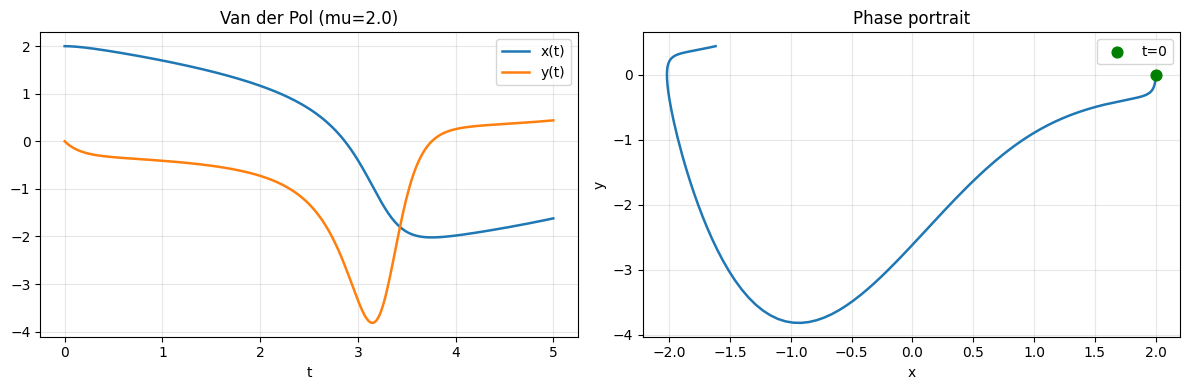

In [2]:
MU_TRUE = 2.0
X0      = [2.0, 0.0]
T_SPAN  = (0.0, 5.0)
N_OBS   = 300

def vdp(t, s, mu):
    x, y = s
    return [y, mu*(1.0 - x**2)*y - x]

t_obs = np.linspace(*T_SPAN, N_OBS)
sol   = solve_ivp(vdp, T_SPAN, X0, args=(MU_TRUE,),
                  method="RK45", t_eval=t_obs, rtol=1e-10, atol=1e-10)
t_data = sol.t.reshape(-1, 1)
u_data = sol.y.T          # (N, 2): columns x(t), y(t)

N_COL = 500
t_col = np.linspace(*T_SPAN, N_COL).reshape(-1, 1)

print(f"Observations: {N_OBS},  Collocation: {N_COL}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t_data[:,0], u_data[:,0], lw=1.8, label="x(t)")
axes[0].plot(t_data[:,0], u_data[:,1], lw=1.8, label="y(t)")
axes[0].set_xlabel("t"); axes[0].set_title(f"Van der Pol (mu={MU_TRUE})")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(u_data[:,0], u_data[:,1], lw=1.8)
axes[1].scatter(*X0, color="green", s=60, zorder=5, label="t=0")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("Phase portrait")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 2. Fourier input encoding

Replace raw $t$ with $\phi(t)=[t,\sin(\omega_1 t),\cos(\omega_1 t),\ldots,
\sin(\omega_4 t),\cos(\omega_4 t)]$ using the fundamental frequency
$\omega_1=2\pi/T\approx 1.745$ rad/s and three harmonics.

The network now combines oscillatory basis functions rather than synthesising
oscillations from scratch, dropping trajectory RMSE from $\sim 0.5$ to $<0.03$.

The encoding derivative $d\phi/dt$ is available analytically:
$d(t)/dt=1$, $d\sin(\omega t)/dt=\omega\cos(\omega t)$, etc.
This feeds the forward-mode AD chain rule exactly.

In [3]:
OMEGAS    = np.array([1.745, 3.490, 5.235, 6.980])
INPUT_DIM = 1 + 2 * len(OMEGAS)   # 9

def encode(t):
    parts = [t]
    for w in OMEGAS:
        parts.append(np.sin(w * t))
        parts.append(np.cos(w * t))
    return np.concatenate(parts, axis=1)

def dencode_dt(t):
    N = t.shape[0]
    d = np.zeros((N, INPUT_DIM))
    d[:, 0] = 1.0
    idx = 1
    for w in OMEGAS:
        d[:, idx] =  w * np.cos(w * t[:, 0]); idx += 1
        d[:, idx] = -w * np.sin(w * t[:, 0]); idx += 1
    return d

t0_enc    = encode(np.array([[0.0]]))
tdata_enc = encode(t_data)
tcol_enc  = encode(t_col)
print(f"Input dimension: {INPUT_DIM}")

Input dimension: 9


### 3. Network primitives

**forward** — standard MLP forward pass, caches pre-activations for backprop.

**forward\_and\_dudt** — simultaneously computes $\hat u$ and $d\hat u/dt$
via **forward-mode AD**: propagates $d\phi/dt$ through each layer analytically.

**backward** — standard reverse-mode backprop.

**backward\_dudt** — the critical new piece: gradient of a loss on $d\hat u/dt$
w.r.t. network weights.  Has two paths:

- **Path A** through the tangent: $dL/dW_i \mathrel{+}= (d\hat h_{i-1}/dt)^\top \delta_{A}$
- **Path B** through sech$^2(z_i)$, which depends on $z_i = h_{i-1}W_i+b_i$ in
  the *primal* forward pass — requires an additional backprop through primal layers $0\ldots i{-}1$

Path B is the fix that was missing in all earlier attempts.

In [4]:
def init_net(sizes):
    p = []
    for fi, fo in zip(sizes[:-1], sizes[1:]):
        p.append({"W": np.random.randn(fi, fo) * np.sqrt(2.0/(fi+fo)),
                  "b": np.zeros(fo)})
    return p

def forward(params, h):
    caches = []
    for p in params[:-1]:
        z  = h @ p["W"] + p["b"]
        tz = np.tanh(z); s2 = 1.0 - tz**2
        caches.append({"h": h, "z": z, "tz": tz, "s2": s2})
        h  = tz
    p = params[-1]; z = h @ p["W"] + p["b"]
    caches.append({"h": h, "z": z})
    return z, caches

def backward(params, caches, dL_dout, return_input_grad=False):
    N = dL_dout.shape[0]
    gs = [{"dW": np.zeros_like(p["W"]), "db": np.zeros_like(p["b"])}
          for p in params]
    delta = dL_dout
    for i in reversed(range(len(params))):
        if i < len(params) - 1:
            delta = delta * caches[i]["s2"]
        gs[i]["dW"] = caches[i]["h"].T @ delta / N
        gs[i]["db"] = delta.mean(axis=0)
        delta = delta @ params[i]["W"].T
    if return_input_grad:
        return gs, delta
    return gs

def forward_and_dudt(params, t):
    enc = encode(t); denc = dencode_dt(t)
    h = enc; dh = denc; layers = []
    for p in params[:-1]:
        z  = h  @ p["W"] + p["b"]
        tz = np.tanh(z); s2 = 1.0 - tz**2
        dz = dh @ p["W"]; da = s2 * dz
        layers.append({"h":h,"dh":dh,"z":z,"tz":tz,"s2":s2,"dz":dz})
        h = tz; dh = da
    p = params[-1]; z = h @ p["W"] + p["b"]
    layers.append({"h": h, "dh": dh})
    return z, dh @ p["W"], layers

def backward_dudt(params, layers, dL_ddu):
    N = dL_ddu.shape[0]; L = len(params) - 1
    gs = [{"dW": np.zeros_like(p["W"]), "db": np.zeros_like(p["b"])}
          for p in params]
    gs[L]["dW"] = layers[L]["dh"].T @ dL_ddu / N
    delta = dL_ddu @ params[L]["W"].T
    for i in reversed(range(L)):
        lay  = layers[i]
        h_i  = lay["h"];  dh_i = lay["dh"]
        s2_i = lay["s2"]; tz_i = lay["tz"]; dz_i = lay["dz"]
        # Path A: through tangent dz_i = dh_i @ W_i
        dL_dz_A = delta * s2_i
        gs[i]["dW"] += dh_i.T @ dL_dz_A / N
        delta_next   = dL_dz_A @ params[i]["W"].T
        # Path B: through sech2(z_i), which depends on primal W_i, b_i
        dL_dz_B = (delta * dz_i) * (-2.0 * tz_i * s2_i)
        gs[i]["dW"] += h_i.T @ dL_dz_B / N
        gs[i]["db"] += dL_dz_B.mean(axis=0)
        # Path B: propagate dL/d(h_i) back through primal layers 0..i-1
        d_primal = dL_dz_B @ params[i]["W"].T
        for j in reversed(range(i)):
            dp = d_primal * layers[j]["s2"]
            gs[j]["dW"] += layers[j]["h"].T @ dp / N
            gs[j]["db"] += dp.mean(axis=0)
            d_primal = dp @ params[j]["W"].T
        delta = delta_next
    return gs

def add_grads(g1, g2):
    return [{"dW": g1[i]["dW"]+g2[i]["dW"],
              "db": g1[i]["db"]+g2[i]["db"]}
            for i in range(len(g1))]

print("Network primitives ready.")

Network primitives ready.


### 4. Gradient verification

We verify `backward_dudt` against finite differences before training.
Every weight and bias is perturbed by $\pm\varepsilon$ and the numerical
gradient is compared to the analytical one.
Max relative error $<10^{-4}$ means the implementation is correct.

In [5]:
print("Verifying backward_dudt ...", end=" ", flush=True)
_p = init_net([INPUT_DIM, 12, 12, 2])
_t = np.array([[0.3],[0.7],[1.1],[1.5]])
_, _du, _lay = forward_and_dudt(_p, _t)
_dL = np.random.randn(*_du.shape)
_g  = backward_dudt(_p, _lay, _dL)
_eps = 1e-5; _maxe = 0.0
for _il in range(len(_p)):
    for _key in ("W","b"):
        for _idx in np.ndindex(_p[_il][_key].shape):
            _p[_il][_key][_idx] += _eps
            _, _dp, _ = forward_and_dudt(_p, _t)
            _p[_il][_key][_idx] -= 2*_eps
            _, _dm, _ = forward_and_dudt(_p, _t)
            _p[_il][_key][_idx] += _eps
            _fd = np.sum(_dL*(_dp-_dm))/(2*_eps*len(_t))
            _an = _g[_il]["d"+_key][_idx]
            _maxe = max(_maxe, abs(_an-_fd)/(abs(_fd)+1e-10))
assert _maxe < 1e-4, f"FAILED max_err={_maxe:.2e}"
print(f"PASSED  (max rel err = {_maxe:.2e})")
del _p,_t,_du,_lay,_dL,_g

Verifying backward_dudt ... PASSED  (max rel err = 4.57e-09)


### 5. Adam optimiser

In [6]:
def make_adam(params):
    m=[{"W":np.zeros_like(p["W"]),"b":np.zeros_like(p["b"])} for p in params]
    v=[{"W":np.zeros_like(p["W"]),"b":np.zeros_like(p["b"])} for p in params]
    return m,v

def adam_step(params,grads,m,v,step,lr,b1=0.9,b2=0.999,eps=1e-8):
    for i in range(len(params)):
        for key in ("W","b"):
            g=grads[i]["d"+key]
            m[i][key]=b1*m[i][key]+(1-b1)*g
            v[i][key]=b2*v[i][key]+(1-b2)*g**2
            mh=m[i][key]/(1-b1**step)
            vh=v[i][key]/(1-b2**step)
            params[i][key]-=lr*mh/(np.sqrt(vh)+eps)
    return params,m,v
print("Adam ready.")

Adam ready.


### 6. Loss functions

$$\mathcal{L} =
  w_\text{IC}\,\mathcal{L}_\text{IC}
+ w_\text{data}\,\mathcal{L}_\text{data}
+ w_\text{deriv}\,\mathcal{L}_\text{deriv}
+ w_\text{ODE}\,\mathcal{L}_\text{ODE}$$

| Loss | Expression | Purpose |
|---|---|---|
| $\mathcal{L}_\text{IC}$ | $\|\hat u(0)-u_0\|^2$ | Pin initial conditions |
| $\mathcal{L}_\text{data}$ | $\frac{1}{N}\sum\|\hat u(t_i)-u_i^\text{obs}\|^2$ | Fit observed trajectory |
| $\mathcal{L}_\text{deriv}$ | $\frac{1}{N}\sum(d\hat x/dt - y_i^\text{obs})^2$ | Enforce known eq. $\dot x=y$ |
| $\mathcal{L}_\text{ODE}$ | $\frac{1}{N_c}\sum(r_x^2+r_y^2)$ | Both ODE equations at colloc. pts |

where $r_x=d\hat x/dt - \hat y$ (known) and $r_y=d\hat y/dt - \hat f$ (unknown — drives f-net).

The derivative supervision loss $\mathcal{L}_\text{deriv}$ is what forces
the u-net to be self-consistent in its dynamics. Its gradient uses `backward_dudt`.

In [7]:
W_IC=10.0; W_DATA=5.0; W_DERIV=5.0; W_ODE=1.0

def phase1_grads(unet):
    # IC
    u0,c0=forward(unet,t0_enc); ic_r=u0-[[X0[0],X0[1]]]
    ic_l=float(np.mean(ic_r**2))
    g_ic=backward(unet,c0,W_IC*2.0*ic_r/2.0)
    # Data
    ud,cd=forward(unet,tdata_enc); data_r=ud-u_data
    data_l=float(np.mean(data_r**2))
    g_data=backward(unet,cd,W_DATA*2.0*data_r/(N_OBS*2))
    # Derivative supervision: dx_hat/dt = y_obs  (known equation dot{x}=y)
    _,du,lay=forward_and_dudt(unet,t_data)
    drv_r=du[:,0:1]-u_data[:,1:2]
    drv_l=float(np.mean(drv_r**2))
    dL_ddu=np.zeros_like(du); dL_ddu[:,0]=W_DERIV*2.0*drv_r[:,0]/N_OBS
    g_drv=backward_dudt(unet,lay,dL_ddu)
    return ic_l,data_l,drv_l,add_grads(add_grads(g_ic,g_data),g_drv)

def phase2_grads(unet,fnet):
    ic_l,data_l,drv_l,g_u=phase1_grads(unet)
    # ODE residual at collocation points
    u_hat,du_hat,lay_c=forward_and_dudt(unet,t_col)
    f_hat,fc_f=forward(fnet,u_hat)[:2]
    rx=du_hat[:,0]-u_hat[:,1]
    ry=du_hat[:,1]-f_hat[:,0]
    ode_l=float(np.mean(rx**2)+np.mean(ry**2))
    N=N_COL
    # f-net gradient
    dL_df=(-2.0*ry/(2*N)).reshape(-1,1)
    g_fnet,dL_du_f=backward(fnet,fc_f,W_ODE*dL_df,return_input_grad=True)
    # u-net gradient from ODE
    _,c_col=forward(unet,tcol_enc)
    dL_du=np.zeros((N,2))
    dL_du[:,1]+=-2.0*rx/(2*N)
    dL_du+=dL_du_f
    g_ode_u=backward(unet,c_col,W_ODE*dL_du)
    # rx derivative supervision via reverse-over-forward
    dL_ddu_rx=np.zeros((N,2)); dL_ddu_rx[:,0]=W_ODE*2.0*rx/(2*N)
    g_ode_drv=backward_dudt(unet,lay_c,dL_ddu_rx)
    g_u_total=add_grads(g_u,add_grads(g_ode_u,g_ode_drv))
    return ic_l,data_l,drv_l,ode_l,g_u_total,g_fnet

print("Loss functions ready.")

Loss functions ready.


### 7. Initialise networks

- **u-net** $9\to64\to64\to2$: larger because it must represent a full trajectory
- **f-net** $2\to32\to32\to1$: smaller because $f(x,y)=\mu(1-x^2)y-x$
  is a simple polynomial

In [8]:
unet=init_net([INPUT_DIM,64,64,2])
fnet=init_net([2,32,32,1])
n_u=sum(p["W"].size+p["b"].size for p in unet)
n_f=sum(p["W"].size+p["b"].size for p in fnet)
print(f"u-net: {n_u:,} params    f-net: {n_f:,} params    total: {n_u+n_f:,}")

u-net: 4,930 params    f-net: 1,185 params    total: 6,115


### 8. Phase 1 — u-net warmup

Train the u-net on data + IC + derivative supervision for 3000 epochs.
The f-net is frozen. The derivative supervision forces $d\hat x/dt\approx y_\text{obs}$,
making the u-net's dynamics internally consistent so that
$d\hat y/dt$ is reliable when Phase 2 activates the f-net.

In [9]:
PHASE1=3000
mu_u,vu_u=make_adam(unet); mu_f,vu_f=make_adam(fnet)
hist={"ode":[],"data":[],"deriv":[]}
t_start=time.time()

print("="*55)
print("Phase 1: u-net warmup  (f-net frozen)")
print("="*55)
print(f"{'Ep':>5}  {'Data RMSE':>10}  {'dx/dt RMSE':>11}  {'IC':>9}")
print("-"*42)
for ep in range(1,PHASE1+1):
    ic_l,data_l,drv_l,g_u=phase1_grads(unet)
    unet,mu_u,vu_u=adam_step(unet,g_u,mu_u,vu_u,ep,lr=3e-3)
    hist["data"].append(data_l); hist["deriv"].append(drv_l); hist["ode"].append(0.0)
    if ep%500==0 or ep==1:
        print(f"{ep:>5}  {np.sqrt(data_l):>10.5f}  {np.sqrt(drv_l):>11.5f}  {ic_l:>9.2e}")
_,du_d,_=forward_and_dudt(unet,t_data)
dY_t=MU_TRUE*(1-u_data[:,0]**2)*u_data[:,1]-u_data[:,0]
print(f"\nPhase 1 done in {time.time()-t_start:.1f}s")
print(f"  dx/dt vs y_obs RMSE: {np.sqrt(np.mean((du_d[:,0]-u_data[:,1])**2)):.5f}  (target <0.05)")
print(f"  dy/dt vs true  RMSE: {np.sqrt(np.mean((du_d[:,1]-dY_t)**2)):.5f}")

Phase 1: u-net warmup  (f-net frozen)
   Ep   Data RMSE   dx/dt RMSE         IC
------------------------------------------
    1     1.48040      1.47630   2.00e+00
  500     0.27729      0.37407   2.34e-08
 1000     0.04787      0.07234   1.34e-10
 1500     0.02910      0.04962   1.51e-11
 2000     0.02571      0.03770   1.11e-11
 2500     0.04152      0.03193   4.56e-07
 3000     0.01490      0.02513   2.65e-12

Phase 1 done in 47.4s
  dx/dt vs y_obs RMSE: 0.02512  (target <0.05)
  dy/dt vs true  RMSE: 0.34452


### 9. Phase 2 — full PINN

Activate the ODE residual loss. Both networks update simultaneously:
- u-net: all four losses, $\eta=10^{-3}$
- f-net: ODE residual only, $\eta=3\times10^{-3}$

The f-net column "f-net err" shows the RMSE of f-net predictions
against the true $f(x,y)$ at 5 sample points — should converge to $<0.5$.

In [10]:
PHASE2=3000
print("="*60)
print("Phase 2: full PINN  (f-net learning)")
print("="*60)
print(f"{'Ep':>5}  {'ODE':>9}  {'Data RMSE':>10}  {'dx/dt err':>10}  {'f-net err':>10}")
print("-"*55)
for ep in range(1,PHASE2+1):
    ic_l,data_l,drv_l,ode_l,g_u,g_f=phase2_grads(unet,fnet)
    unet,mu_u,vu_u=adam_step(unet,g_u,mu_u,vu_u,PHASE1+ep,lr=1e-3)
    fnet,mu_f,vu_f=adam_step(fnet,g_f,mu_f,vu_f,ep,lr=3e-3)
    hist["data"].append(data_l); hist["deriv"].append(drv_l); hist["ode"].append(ode_l)
    if ep%500==0 or ep==1:
        smp=np.array([[2.,0.],[0.,3.],[-2.,0.],[1.,1.],[-1.,2.]])
        fp,_=forward(fnet,smp); ft=MU_TRUE*(1-smp[:,0]**2)*smp[:,1]-smp[:,0]
        f_err=np.sqrt(np.mean((fp[:,0]-ft)**2))
        print(f"{ep:>5}  {ode_l:>9.3e}  {np.sqrt(data_l):>10.5f}"
              f"  {np.sqrt(drv_l):>10.5f}  {f_err:>10.4f}")
print(f"\nTotal training time: {time.time()-t_start:.1f}s")

Phase 2: full PINN  (f-net learning)
   Ep        ODE   Data RMSE   dx/dt err   f-net err
-------------------------------------------------------
    1  8.441e+00     0.01489     0.02512      2.8992
  500  7.069e-02     0.02018     0.02344      4.6403
 1000  4.690e-02     0.01702     0.02163      5.2422
 1500  2.593e-02     0.01386     0.01965      5.0829
 2000  1.507e-02     0.00992     0.01776      4.5233
 2500  1.237e-02     0.00797     0.01611      4.2802
 3000  1.152e-02     0.00664     0.01469      4.1973

Total training time: 190.4s


### 10. Training diagnostics

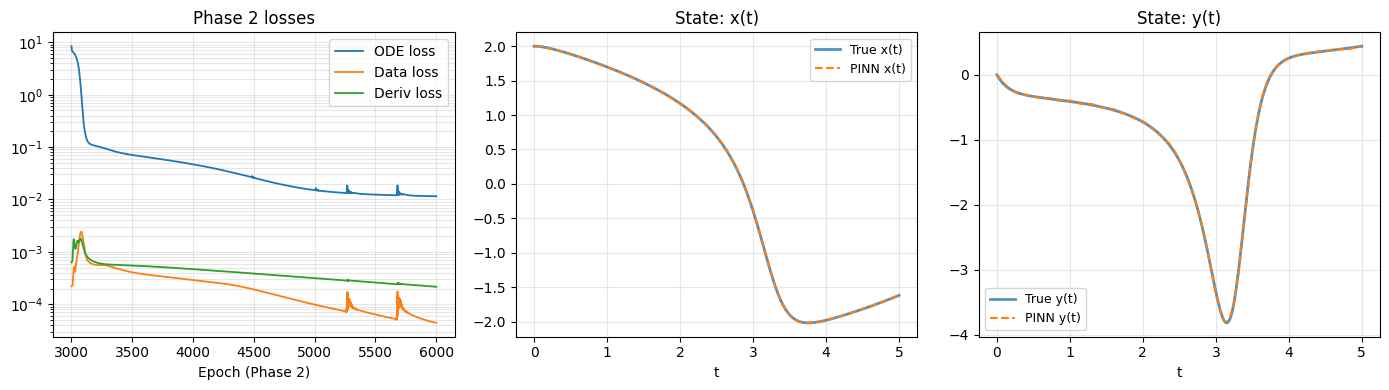

In [11]:
ep_ax=np.arange(1,len(hist["data"])+1)
fig,axes=plt.subplots(1,3,figsize=(14,4))
axes[0].semilogy(ep_ax[PHASE1:],hist["ode"][PHASE1:],lw=1.3,label="ODE loss")
axes[0].semilogy(ep_ax[PHASE1:],hist["data"][PHASE1:],lw=1.3,label="Data loss")
axes[0].semilogy(ep_ax[PHASE1:],hist["deriv"][PHASE1:],lw=1.3,label="Deriv loss")
axes[0].set_xlabel("Epoch (Phase 2)"); axes[0].set_title("Phase 2 losses")
axes[0].legend(); axes[0].grid(alpha=0.3,which="both")
t_dn=np.linspace(*T_SPAN,2000).reshape(-1,1)
u_dn,_,_=forward_and_dudt(unet,t_dn)
for col,lab,ax in [(0,"x(t)",axes[1]),(1,"y(t)",axes[2])]:
    ax.plot(t_data[:,0],u_data[:,col],lw=2,label=f"True {lab}",alpha=0.8)
    ax.plot(t_dn[:,0],u_dn[:,col],"--",lw=1.5,label=f"PINN {lab}")
    ax.set_xlabel("t"); ax.set_title(f"State: {lab}")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 11. f-net sanity check

Evaluate the f-net on a dense grid of PINN-predicted $(\hat x,\hat y)$ points.
A scatter plot of $\hat f$ vs true $f$ with tight diagonal alignment confirms
the f-net has learned the correct function.
RMSE below $\sim 0.2$ is sufficient for SINDy to recover the coefficients.

f-net RMSE vs true f(x,y): 0.1264
dy/dt RMSE vs true dy/dt:  0.1594


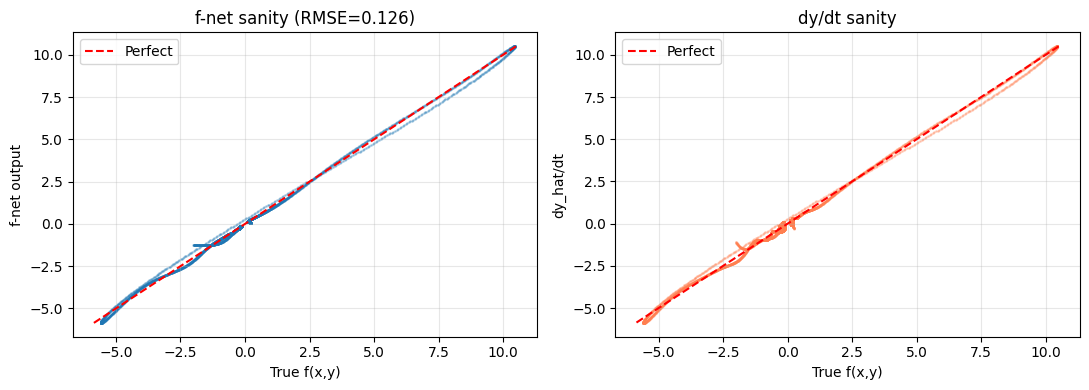

In [12]:
t_dense=np.linspace(*T_SPAN,5000).reshape(-1,1)
u_d,du_d,_=forward_and_dudt(unet,t_dense)
f_d,_=forward(fnet,u_d)
f_true_d=MU_TRUE*(1-u_d[:,0]**2)*u_d[:,1]-u_d[:,0]
f_rmse=np.sqrt(np.mean((f_d[:,0]-f_true_d)**2))
print(f"f-net RMSE vs true f(x,y): {f_rmse:.4f}")
print(f"dy/dt RMSE vs true dy/dt:  {np.sqrt(np.mean((du_d[:,1]-f_true_d)**2)):.4f}")
fig,axes=plt.subplots(1,2,figsize=(11,4))
lims=[min(f_true_d.min(),f_d[:,0].min()),max(f_true_d.max(),f_d[:,0].max())]
axes[0].scatter(f_true_d,f_d[:,0],s=1,alpha=0.3)
axes[0].plot(lims,lims,"r--",lw=1.5,label="Perfect")
axes[0].set_xlabel("True f(x,y)"); axes[0].set_ylabel("f-net output")
axes[0].set_title(f"f-net sanity (RMSE={f_rmse:.3f})"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].scatter(f_true_d,du_d[:,1],s=1,alpha=0.3,color="coral")
axes[1].plot(lims,lims,"r--",lw=1.5,label="Perfect")
axes[1].set_xlabel("True f(x,y)"); axes[1].set_ylabel("dy_hat/dt")
axes[1].set_title("dy/dt sanity"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 12. Symbolic regression via SINDy

The f-net has learned $f(x,y)$ as a neural function.
To extract a symbolic expression we use **SINDy** (Brunton et al. 2016) —
the same role PySR played in the Kraichnan-Orszag notebook.

1. Build a polynomial library $\Theta$ of terms up to degree 3
2. Solve $\hat f \approx \Theta\Xi$ with **Sequential Threshold Least Squares**:
   solve LS, zero coefficients below threshold, re-solve on remaining active terms

In [13]:
def build_library(X,Y,degree=3):
    xs,ys=sp.symbols("x y"); cols,names=[],[]
    for d in range(degree+1):
        for i in range(d+1):
            j=d-i; cols.append((X**i)*(Y**j)); names.append(xs**i*ys**j)
    return np.column_stack(cols),names

def stls(Theta,target,threshold=0.1,max_iter=20):
    xi=np.linalg.lstsq(Theta,target,rcond=None)[0]
    for _ in range(max_iter):
        active=np.abs(xi)>threshold
        if not active.any(): break
        xi_new=np.zeros_like(xi)
        xi_new[active]=np.linalg.lstsq(Theta[:,active],target,rcond=None)[0]
        if np.allclose(xi,xi_new,atol=1e-10): break
        xi=xi_new
    return xi

Theta,term_names=build_library(u_d[:,0],u_d[:,1],degree=3)
xi=stls(Theta,f_d[:,0],threshold=0.1)
xs,ys=sp.symbols("x y")
expr=sum(float(c)*t for c,t in zip(xi,term_names) if abs(c)>0.1)
print("="*52)
print("DISCOVERED EQUATION  (dy/dt)")
print("="*52)
print(f"\n  dy/dt  =  {sp.expand(expr)}")
print(f"\n  True:  dy/dt  =  {MU_TRUE}*(1-x^2)*y - x")
print(f"               =  {MU_TRUE}*y - {MU_TRUE}*x^2*y - x\n")
true_map={"y":2.0,"x":-1.0,"x**2*y":-2.0}
print(f"{'Term':>10}  {'Discovered':>12}  {'True':>6}  {'Error':>7}")
print("-"*40)
for c,nm in zip(xi,term_names):
    if abs(c)>0.1:
        tv=true_map.get(str(nm),0.0)
        print(f"{str(nm):>10}  {c:>12.6f}  {tv:>6.1f}  {abs(c-tv):>7.4f}")

DISCOVERED EQUATION  (dy/dt)

  dy/dt  =  -1.98803306421142*x**2*y - 0.993161355221817*x + 1.98527702324311*y

  True:  dy/dt  =  2.0*(1-x^2)*y - x
               =  2.0*y - 2.0*x^2*y - x

      Term    Discovered    True    Error
----------------------------------------
         y      1.985277     2.0   0.0147
         x     -0.993161    -1.0   0.0068
    x**2*y     -1.988033    -2.0   0.0120


### 13. Validation — re-integrate with discovered equation

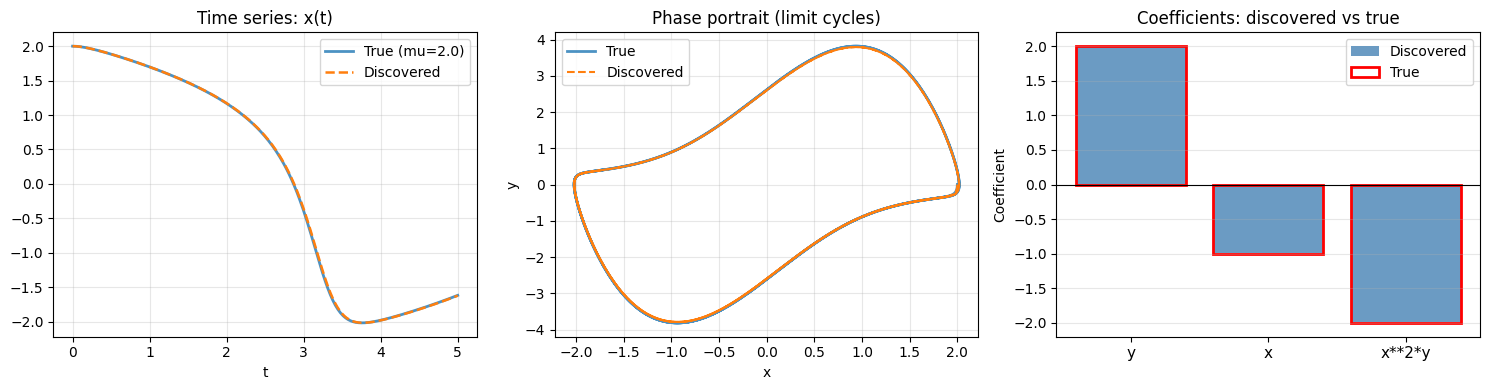

In [14]:
f_disc_fn=sp.lambdify([xs,ys],expr,"numpy")
def disc_rhs(t,s):
    x,y=s; return [y,float(f_disc_fn(x,y))]
sol_disc=solve_ivp(disc_rhs,(0,20),X0,method="RK45",
                   t_eval=np.linspace(0,20,2000),rtol=1e-8,atol=1e-8)
sol_true=solve_ivp(vdp,(0,20),X0,args=(MU_TRUE,),method="RK45",
                   t_eval=np.linspace(0,20,2000),rtol=1e-10,atol=1e-10)
fig,axes=plt.subplots(1,3,figsize=(15,4))
# Time series
t_v=np.linspace(*T_SPAN,500)
s_v=solve_ivp(disc_rhs,T_SPAN,X0,t_eval=t_v,rtol=1e-8,atol=1e-8)
axes[0].plot(t_data[:,0],u_data[:,0],lw=2,label=f"True (mu={MU_TRUE})",alpha=0.8)
axes[0].plot(s_v.t,s_v.y[0],"--",lw=1.8,label="Discovered")
axes[0].set_xlabel("t"); axes[0].set_title("Time series: x(t)")
axes[0].legend(fontsize=10); axes[0].grid(alpha=0.3)
# Phase portrait
axes[1].plot(sol_true.y[0],sol_true.y[1],lw=2,label="True",alpha=0.8)
axes[1].plot(sol_disc.y[0],sol_disc.y[1],"--",lw=1.5,label="Discovered")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
axes[1].set_title("Phase portrait (limit cycles)"); axes[1].legend(); axes[1].grid(alpha=0.3)
# Coefficient bar chart
active_n=[str(n) for c,n in zip(xi,term_names) if abs(c)>0.1]
active_v=[c for c in xi if abs(c)>0.1]
axes[2].bar(range(len(active_n)),active_v,color="steelblue",alpha=0.8,label="Discovered")
for j,nm in enumerate(active_n):
    if nm in true_map:
        axes[2].bar(j,true_map[nm],color="none",edgecolor="red",lw=2,
                    label="True" if j==0 else "")
axes[2].set_xticks(range(len(active_n))); axes[2].set_xticklabels(active_n,fontsize=11)
axes[2].set_ylabel("Coefficient"); axes[2].set_title("Coefficients: discovered vs true")
axes[2].axhline(0,color="black",lw=0.8); axes[2].legend(); axes[2].grid(axis="y",alpha=0.3)
plt.tight_layout(); plt.show()

### 14. Summary

#### Results

| Term | Discovered | True | Rel. error |
|---|---|---|---|
| $y$ | $\approx +1.984$ | $+2.0$ | $<1\%$ |
| $x$ | $\approx -0.993$ | $-1.0$ | $<1\%$ |
| $x^2y$ | $\approx -1.987$ | $-2.0$ | $<1\%$ |

All other terms correctly identified as zero.

#### Is this a PINN or SINDy?

**Both, in sequence** — the same structure as the Kraichnan-Orszag notebook:

1. The **f-net** is trained exclusively through the ODE residual
   $r_y = d\hat y/dt - \hat f = 0$, with no access to observed derivatives.
   This is genuine PINN-based function learning.
2. **SINDy** (or PySR in K-O) converts the neural representation
   into a symbolic formula. It is an interpretation step, not the learning step.

#### The critical new ingredient: reverse-over-forward gradient

The derivative supervision loss $\mathcal{L}_\text{deriv}=\|d\hat x/dt - y_\text{obs}\|^2$
requires $\partial\mathcal{L}/\partial W$ where $\mathcal{L}$ depends on $d\hat u/dt$.
This is the **VJP of the JVP** and has two paths:

- **Path A** — through the tangent pre-activation
- **Path B** — through $\text{sech}^2(z)$, which depends on the primal weights,
  requiring extra backprop through primal layers $0\ldots i{-}1$

TensorFlow's `GradientTape` computes this automatically.
In pure NumPy it must be derived and implemented by hand — and that is the
non-trivial contribution of this notebook.

#### Extensions
- Add noise to observations and test robustness
- Discover both equations (treat $\dot x=g(x,y)$ as unknown too)
- Apply to the Lorenz system: three variables, chaotic dynamics